# Based on pytorch tutorial. Changed network to dueling double dqn

https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

In [1]:
import math
import random
from collections import deque, namedtuple

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import optim

from src.networks.dueling_dqn import DuelingDQN


In [2]:
env = gym.make("CartPole-v1")

In [3]:
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
device

device(type='mps')

In [5]:

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

training_queue = ReplayMemory(capacity=10_000)



## Chages here

In [6]:
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4

In [7]:
n_actions = env.action_space.n

In [8]:
state, info = env.reset()
n_observations = len(state)

In [9]:
policy_net = DuelingDQN(n_observations, n_actions).to(device)
target_net = DuelingDQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

<All keys matched successfully>

## Here

In [10]:
optimizer = optim.Adam(policy_net.parameters(), lr=LR)

In [11]:
steps_done = 0
def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1

    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    
    return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [12]:
episode_durations = []
def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

## And here: MSE loss; Double dqn

In [13]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

def optimize_model():
    if len(training_queue) < BATCH_SIZE:
        return
    transitions = training_queue.sample(BATCH_SIZE)

    batch = Transition(*zip(*transitions))

    non_final_mask = torch.tensor(tuple(s is not None for s in batch.next_state), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)

    with torch.no_grad():
        best_actions = policy_net(non_final_next_states).argmax(1, keepdim=True)
        next_state_values[non_final_mask] = target_net(non_final_next_states).gather(1, best_actions).squeeze(1)

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    loss = F.mse_loss(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



In [14]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 50

Complete


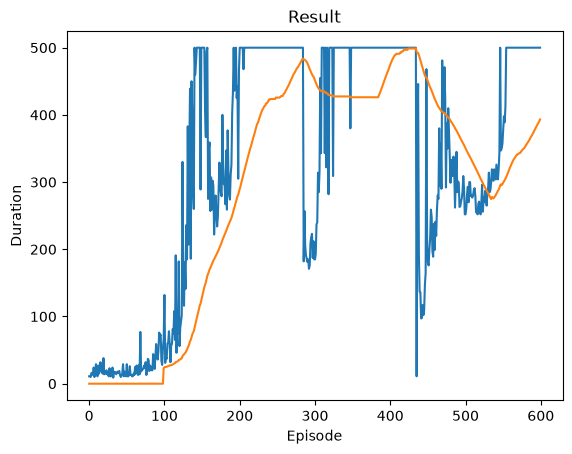

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    done = False

    t = 0
    while not done:
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        reward = torch.tensor([reward], device=device)

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        training_queue.push(state, action, next_state, reward)

        state = next_state

        optimize_model()

        # soft update
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)
        
        t += 1

    episode_durations.append(t)
    plot_durations()

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

In [16]:
import numpy as np
from tqdm import tqdm

test_env = gym.make("CartPole-v1", render_mode=None)
state, info = test_env.reset()
n_actions = test_env.action_space.n
n_observations = len(state)


test_agent = DuelingDQN(n_observations, n_actions).to(device)
test_agent.load_state_dict(policy_net.state_dict())

test_reward = []

for n in tqdm(range(1000)):
    state, _ = test_env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            action = test_agent.forward(state).max(1).indices.view(1, 1)

        next_state, reward, terminated, truncated, _ = test_env.step(action.item())
        next_state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
        
        done = terminated or truncated
        state = next_state
        total_reward += reward

    test_reward.append(total_reward)


print("avg: ", np.average(test_reward))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [06:13<00:00,  2.68it/s]

avg:  500.0


In [17]:
from safetensors.torch import save_file

save_file(policy_net.state_dict(), "./data/dueling_e600_128.safetensors")
